# LSTM vs GRU 성능 & 속도 비교

**IMDB 영화 리뷰 감성 분류** 문제를 통해 LSTM과 GRU 두 모델을 직접 비교해보겠습니다 !

> **실행 방법: Colab 상단 메뉴에서 `연결 > 런타임 유형 변경 > T4 GPU`로 설정한 뒤, 각 셀을 위에서부터 순서대로 실행해주세요.**

## 0. 실습 개요

**태스크**: IMDB 영화 리뷰가 긍정(1)인지 부정(0)인지 분류하는 이진 분류 문제

임베딩 층(Embedding) + 순환층(LSTM 또는 GRU) + 출력층(Dense) 구조를 동일하게 맞추고, 순환층만 LSTM ↔ GRU로 바꿔서 공정하게 비교.

## 1단계. 라이브러리 불러오기 및 GPU 확인

먼저 필요한 라이브러리를 불러오고, GPU가 잘 연결되어 있는지 확인합니다.
GPU가 없으면 학습 시간이 훨씬 오래 걸리니 꼭 확인해주세요!

In [3]:
# 나눔고딕 설치
!apt-get update -qq
!apt-get install -qq fonts-nanum
!fc-cache -fv > /dev/null

# Matplotlib에 폰트 등록
import glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for font_path in glob.glob('/usr/share/fonts/truetype/nanum/*.ttf'):
    fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("현재 적용 폰트:", plt.rcParams['font.family'])

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
현재 적용 폰트: ['NanumGothic']


In [4]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense

# 재현성을 위한 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

# GPU 사용 가능 여부 확인
print("사용 가능한 장치:")
print(tf.config.list_physical_devices('GPU'))
if len(tf.config.list_physical_devices('GPU')) == 0:
    print("⚠️ GPU가 연결되어 있지 않습니다. 연결 > 런타임 유형 변경 > T4 GPU로 설정해주세요.")
else:
    print("✅ GPU 연결 확인 완료!")


사용 가능한 장치:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU 연결 확인 완료!


## 2단계. 데이터 준비 (IMDB 영화 리뷰)

*Keras에는 IMDB 영화 리뷰 5만 건이 내장되어 있습니다.
단어는 이미 정수 인덱스로 변환되어 있어서 바로 학습에 사용할 수 있습니다.

- `vocab_size`: 등장 빈도 상위 몇 개의 단어만 사용할지 (나머지는 무시)
   
   *keras에 있는 모든 단어를 사용하기에는 시간이 너무 오래걸림
- `max_len`: 리뷰 하나당 최대 단어 길이 (넘으면 자르고, 모자라면 0으로 채움 → padding)
   
   *문장 길이 맞추기

In [5]:
# 하이퍼파라미터 설정
vocab_size = 10000    # 상위 10,000개 단어만 사용
max_len = 200         # 리뷰 하나당 최대 200단어
embedding_dim = 32    # 임베딩 벡터 차원

# 데이터 로드 (처음 실행 시 자동 다운로드됨)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"학습 데이터 개수: {len(x_train)}")
print(f"테스트 데이터 개수: {len(x_test)}")
print(f"첫 번째 리뷰(정수 인덱스, 앞 20개): {x_train[0][:20]}")
print(f"첫 번째 리뷰의 라벨: {y_train[0]} (1=긍정, 0=부정)")

# 리뷰 길이를 max_len으로 통일 (padding)
x_train = pad_sequences(x_train, maxlen=max_len, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post', truncating='post')

print(f"\npadding 후 shape: {x_train.shape}  (샘플 수, 시퀀스 길이)")


학습 데이터 개수: 25000
테스트 데이터 개수: 25000
첫 번째 리뷰(정수 인덱스, 앞 20개): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
첫 번째 리뷰의 라벨: 1 (1=긍정, 0=부정)

padding 후 shape: (25000, 200)  (샘플 수, 시퀀스 길이)


## 3단계. 모델 설계

**공정한 비교**를 위해 두 모델은 딱 한 층(LSTM ↔ GRU)만 다르고 나머지 구조는 동일합니다.

```
입력 시퀀스
   ↓
Embedding (단어 → 벡터)
   ↓
LSTM 또는 GRU (시퀀스 정보 요약)
   ↓
Dense (이진 분류, sigmoid)
   ↓
출력 (0~1 사이 확률)
```

### 3-2. LSTM 셀 직접 구현해보기


LSTM은 셀 상태 $c_t$와 은닉 상태 $h_t$ 두 개를 함께 관리하고, 게이트가 3개(망각/입력/출력)입니다.

$$f_t = \sigma(x_t W_f + h_{t-1} U_f + b_f) \quad \text{(망각 게이트)}$$
$$i_t = \sigma(x_t W_i + h_{t-1} U_i + b_i) \quad \text{(입력 게이트)}$$
$$o_t = \sigma(x_t W_o + h_{t-1} U_o + b_o) \quad \text{(출력 게이트)}$$
$$\tilde c_t = \tanh(x_t W_c + h_{t-1} U_c + b_c) \quad \text{(후보 셀상태)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t \quad \text{(셀 상태 갱신)}$$
$$h_t = o_t \odot \tanh(c_t) \quad \text{(은닉 상태 갱신)}$$

In [6]:
class LSTMCellCustom(tf.keras.layers.Layer):

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units] # LSTM은 상태가 2개(h, c)이므로 리스트로 지정
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        u = self.units

        # --- 망각 게이트(f_t) ---
        self.Wf = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wf')
        self.Uf = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uf')
        self.bf = self.add_weight(shape=(u,), initializer='ones', name='bf')  # 초기값 1: 학습 초반 정보를 잘 유지하도록

        # --- 입력 게이트(i_t) ---
        self.Wi = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wi')
        self.Ui = self.add_weight(shape=(u, u), initializer='orthogonal', name='Ui')
        self.bi = self.add_weight(shape=(u,), initializer='zeros', name='bi')

        # --- 출력 게이트(o_t) ---
        self.Wo = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wo')
        self.Uo = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uo')
        self.bo = self.add_weight(shape=(u,), initializer='zeros', name='bo')

        # --- 후보 셀상태(c_tilde) ---
        self.Wc = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wc')
        self.Uc = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uc')
        self.bc = self.add_weight(shape=(u,), initializer='zeros', name='bc')

        super().build(input_shape)

    def call(self, inputs, states):
        # states[0]: 이전 은닉상태 h_{t-1},  states[1]: 이전 셀상태 c_{t-1}
        x_t = inputs
        h_prev, c_prev = states

        # 식을 참고해서 코드 작성해주세요
        # 망각 게이트
        f_t = tf.sigmoid(tf.matmul(x_t, self.Wf) + tf.matmul(h_prev, self.Uf) + self.bf)

        # 입력 게이트
        i_t = tf.sigmoid(tf.matmul(x_t, self.Wi) + tf.matmul(h_prev, self.Ui) + self.bi)

        # 출력 게이트
        o_t = tf.sigmoid(tf.matmul(x_t, self.Wo) + tf.matmul(h_prev, self.Uo) + self.bo)

        c_tilde = tf.tanh(tf.matmul(x_t, self.Wc) + tf.matmul(h_prev, self.Uc) + self.bc)

        c_t = f_t * c_prev + i_t * c_tilde
        h_t = o_t * tf.tanh(c_t)

        return h_t, [h_t, c_t]


<details>
<summary> HINT </summary>

tf.sigmoid, tf.matmul, tf.tanh 활용해서 식을 작성해주시면 됩니다 !

</details>

### 3-1. GRU 셀 직접 구현해보기

앞서 배운 GRU 수식을 그대로 코드로 옮기면 다음과 같습니다.

$$r_t = \sigma(x_t W_r + h_{t-1} U_r + b_r) \quad \text{(리셋 게이트)}$$
$$z_t = \sigma(x_t W_z + h_{t-1} U_z + b_z) \quad \text{(업데이트 게이트)}$$
$$\tilde h_t = \tanh(x_t W_h + (r_t \odot h_{t-1}) U_h + b_h) \quad \text{(후보 은닉상태)}$$
$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde h_t \quad \text{(최종 은닉상태)}$$

`tf.keras.layers.RNN`이 시간 축(time step)을 따라 이 셀을 자동으로 반복 호출해줍니다.
우리는 **한 시점(time step)에서 무슨 계산이 일어나는지**만 `call()` 안에 정의하면 됩니다.

In [7]:
class GRUCellCustom(tf.keras.layers.Layer):

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        u = self.units

        # --- 리셋 게이트(r_t) 파라미터: W_r, U_r, b_r ---
        self.Wr = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wr')
        self.Ur = self.add_weight(shape=(u, u), initializer='orthogonal', name='Ur')
        self.br = self.add_weight(shape=(u,), initializer='zeros', name='br')

        # --- 업데이트 게이트(z_t) 파라미터: W_z, U_z, b_z ---
        self.Wz = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wz')
        self.Uz = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uz')
        self.bz = self.add_weight(shape=(u,), initializer='zeros', name='bz')

        # --- 후보 은닉상태(h_tilde) 파라미터: W_h, U_h, b_h ---
        self.Wh = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wh')
        self.Uh = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uh')
        self.bh = self.add_weight(shape=(u,), initializer='zeros', name='bh')

        super().build(input_shape)

    def call(self, inputs, states):
        # inputs: 현재 시점의 입력 x_t,  states[0]: 이전 은닉상태 h_{t-1}
        x_t = inputs
        h_prev = states[0]

        # 식을 참고해서 코드 작성해주세요.
        # 리셋 게이트
        r_t = tf.sigmoid(tf.matmul(x_t, self.Wr) + tf.matmul(h_prev, self.Ur) + self.br)

        # 업데이트 게이트
        z_t = tf.sigmoid(tf.matmul(x_t, self.Wz) + tf.matmul(h_prev, self.Uz) + self.bz)

        # 후보 은닉상태
        h_tilde = tf.tanh(tf.matmul(x_t, self.Wh) + tf.matmul(r_t * h_prev, self.Uh) + self.bh)

        # 최종 은닉상태
        h_t = (1 - z_t) * h_prev + z_t * h_tilde


        return h_t, [h_t]


### 3-3. 모델 불러오기

실제로는 tensorflow에서 LSTM과 GRU를 제공합니다. 라이브러리 호출해서 비교해보겠습니다.

In [25]:
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU

RNN_units = 10
batch_size = 500
epochs = 15

# 모델 생성 함수 정의
def build_model(cell_type):
    model = Sequential()
    # 1) 단어 임베딩: 입력 시퀀스를 EMB_DIM 차원 벡터로 변환
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embedding_dim,
                        input_length=max_len))
    # 2) 순환 셀 추가
    if cell_type == 'RNN':
        model.add(SimpleRNN(RNN_units))
    elif cell_type == 'LSTM':
        model.add(LSTM(RNN_units))
    elif cell_type == 'GRU':
        model.add(GRU(RNN_units))
    # 3) 출력층: sigmoid 활성화로 이진 분류
    model.add(Dense(1, activation='sigmoid'))

    # 4) 컴파일: Adam 옵티마이저, binary_crossentropy 손실, 정확도 지표
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

**참고**: `summary()` 결과에서 `Total params`를 비교해보세요.
같은 `hidden_units`를 사용해도 LSTM은 게이트(가중치 세트)가 4개(f, i, o, c_tilde), GRU는 3개(r, z, h_tilde)이기 때문에
**LSTM의 파라미터 수가 GRU보다 약 1.33배(≈4/3) 많습니다.**
(순환층 파라미터 수: LSTM = 4 × (게이트당 파라미터), GRU = 3 × (게이트당 파라미터))

> 💡 `tf.keras.layers.LSTM` / `GRU` 같은 내장 레이어는 내부적으로 cuDNN 가속을 사용해서
> 우리가 만든 커스텀 셀보다 학습 속도가 훨씬 빠릅니다. 즉, 이번 실습의 속도 비교는
> **"직접 구현한 두 모델끼리의 상대적인 속도 차이"**를 보는 것이지, 실무에서 쓰는
> 최적화된 라이브러리 성능을 재는 것은 아니라는 점을 기억해주세요.

## 4단계. 모델 학습 및 결과 저장



In [26]:
# 에포크 타이머
import time

class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._epoch_start
        self.epoch_times.append(elapsed)

results = {}
for cell in ['RNN', 'LSTM', 'GRU']:
    print(f'▶ {cell} 모델 학습 시작...')
    model   = build_model(cell)
    timer = EpochTimer()

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=2,
        callbacks=[timer]
    )

    results[cell] = {
        'history': history.history,
        'avg_epoch_time': np.mean(timer.epoch_times),
    }

    print(f' {cell} → 평균 에폭 시간: {results[cell]["avg_epoch_time"]:.2f}초 ')

▶ RNN 모델 학습 시작...
Epoch 1/15
40/40 - 5s - 118ms/step - accuracy: 0.5465 - loss: 0.6875 - val_accuracy: 0.6942 - val_loss: 0.6399
Epoch 2/15
40/40 - 1s - 20ms/step - accuracy: 0.6493 - loss: 0.6657 - val_accuracy: 0.7804 - val_loss: 0.5592
Epoch 3/15
40/40 - 1s - 20ms/step - accuracy: 0.6508 - loss: 0.6573 - val_accuracy: 0.6110 - val_loss: 0.6801
Epoch 4/15
40/40 - 1s - 20ms/step - accuracy: 0.6668 - loss: 0.6095 - val_accuracy: 0.6348 - val_loss: 0.6381
Epoch 5/15
40/40 - 1s - 20ms/step - accuracy: 0.7390 - loss: 0.5423 - val_accuracy: 0.6154 - val_loss: 0.6769
Epoch 6/15
40/40 - 1s - 20ms/step - accuracy: 0.7645 - loss: 0.5231 - val_accuracy: 0.7818 - val_loss: 0.5262
Epoch 7/15
40/40 - 1s - 20ms/step - accuracy: 0.8114 - loss: 0.4571 - val_accuracy: 0.8080 - val_loss: 0.4927
Epoch 8/15
40/40 - 1s - 20ms/step - accuracy: 0.8708 - loss: 0.3815 - val_accuracy: 0.8062 - val_loss: 0.4885
Epoch 9/15
40/40 - 1s - 20ms/step - accuracy: 0.8896 - loss: 0.3377 - val_accuracy: 0.8132 - val_loss

## 5단계. 학습 결과 시각화

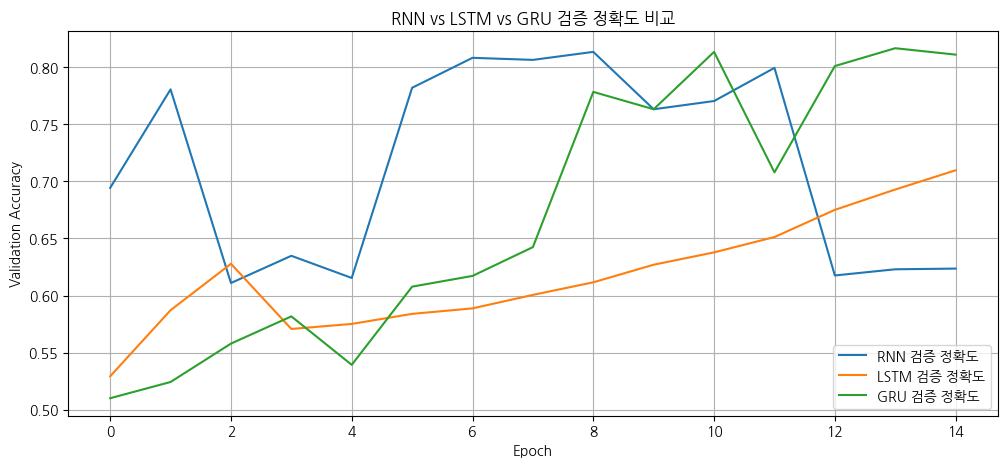

In [27]:
plt.figure(figsize=(12, 5))
for cell in results:
    plt.plot(results[cell]['history']['val_accuracy'],
             label=f'{cell} 검증 정확도')
plt.title('RNN vs LSTM vs GRU 검증 정확도 비교')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 6단계. 생각해봐주세요 !

실습 결과를 바탕으로 아래 질문에 답해보세요.

1. **정확도**: RNN, LSTM과 GRU 중 어느 모델의 테스트 정확도가 더 높나요? 그 차이가 통계적으로 유의미해 보이는 수준인가요, 아니면 오차 범위 수준인가요? 결과가 왜 이렇게 나왔는지 이유까지 설명해주세요.

    테스트 정확도는 GRU, LSTM, RNN 순으로 나타났으며, GRU와 LSTM의 차이는 크지 않아 통계적으로 유의미하다기보다는 오차 범위 수준에 가깝다. RNN은 문장이 길어질수록 앞부분의 정보를 뒤까지 전달하기 어렵기 때문에 정확도가 낮게 나온다. 하지만 LSTM과 GRU는 게이트를 이용해 필요한 정보를 선택적으로 기억할 수 있기 때문에 일반 RNN보다 긴 문장의 정보를 잘 학습할 수 있다.
    

2. **속도**: 학습 시간과 추론 시간에서 GRU가 LSTM보다 빨랐나요? 그 차이가 통계적으로 유의미해 보이는 수준인가요, 아니면 오차 범위 수준인가요? 결과가 왜 이렇게 나왔는지 이유까지 설명해주세요.

    GRU가 LSTM보다 조금 빨랐지만 통계적으로 유의미해 보이지는 않는다. GRU는 업데이트 게이트와 리셋 게이트만 사용해서 구조가 단순하지만 LSTM은 입력, 망각, 출력 게이트와 별도의 셀 상태까지 계산한다. 따라서 같은 유닛 수를 사용하면 GRU의 파라미터 수와 계산량이 더 적어 LSTM보다 빠르게 실행된다.

3. **하이퍼파라미터 실험**: `RNN_units`나 `epochs`, `max_len`, 'batch_size' 등을  바꿔가며 다시 실행해보고, 결과가 어떻게 달라지는지 관찰해보세요.
    
    - units, epochs: 처음에는 해당 파라미터를 늘릴 수록 정확도도 높아졌지만 일정 값 이상으로 크게 설정하면 정확도는 비슷하게 나오고 학습 시간만 길어졌다.
    - max_len: 너무 짧으면 문장이 잘렸고 너무 길면 패딩이 많아졌다.
    - batch_size: 키울 수록 학습은 빨라졌지만 정확도 차이는 크지 않았다.

**정답을 원하는 것이 아닙니다. 실습만 해보는 것이 아니라 결과에 대해 고민해보는 시간을 가지셨으면 좋겠습니다 ! 그럼 다들 BASE 활동 파이팅 하세요 😊**